# OPRD-100 vs Reaxys Dataset Comparison

This notebook compares the OPRD-100 dataset with the Reaxys dataset extracted from the same 100 articles.

## Overview

The comparison analyzes:
1. **Data Location**: Where reaction data appears in articles (schemes, tables, experimental sections)
2. **Yield Types**: Types and distributions of yield metrics reported
3. **Yield Distributions**: Numerical yield values across different locations
4. **Reaction Networks**: Molecules (nodes) and reactions (edges) captured by each dataset
5. **Stereochemistry**: Stereochemical differences and conflicts
6. **Molecule Classification**: Identification of intermediates vs reagents
7. **Summary Visualizations**: Comprehensive comparison plots
8. **Example Networks**: Specific article reaction network visualizations

In [3]:
# Add src directory to Python path for imports
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))

# Standardize plot size and font for matplotlib

figsize=(3, 2)
title_fontdict={'fontsize':14,'fontweight':'bold'}
label_fontdict={'fontsize':14}
tick_fontdict={'fontsize':14,'fontweight':'bold'}
legend_fontdict={'size':14}

def _has_value(v):
    """Checks if a value is None or a list of None values."""
    if v is None:
        return False
    if isinstance(v, str):
        if not v.strip():
            return False
        if v.lower() in {None, "null", "none", "nan"}:
            return False
    if isinstance(v, list):
        if not v:
            return False
        if all(item is None for item in v):
            return False
    return True


## Setup and Configuration

Configure plotting parameters and define utility functions.

[21:02:55] WARNING: not removing hydrogen atom without neighbors
[21:02:55] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:02:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:02:55] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:02:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:02:55] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:02:55] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:02:55] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:02:56] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:02:56] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:02:56] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:02:56]

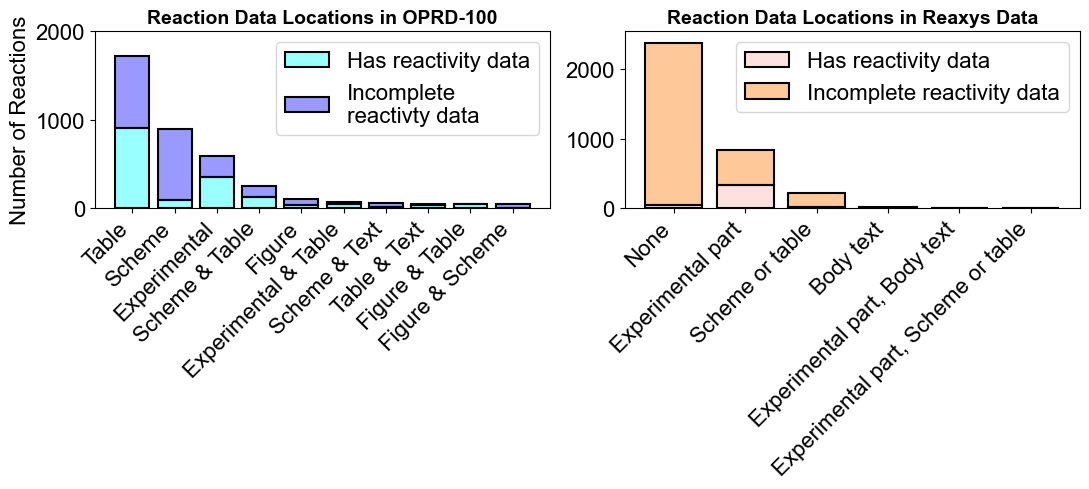

In [4]:
# What are the locations of reaxys data
from ReaxysComparison import ReaxysDataExtractor
import pandas as pd
import re
import os
from PlottingFunctions import Plot
filepath = "../output/reaxys_comparison_figures/"

# Read in the processed OPRD-100 data
import json
import re
from collections import defaultdict
import numpy as np

class ReactionDataExtractor:

    

    def __init__(self, json_file=None):
        """
        Accepts a JSON file containing a list of reaction dicts.
        .
        """
        if json_file is not None:
            with open(json_file, 'r') as f:
                self.data = json.load(f)
        self.total_count = 0
        

    def parse_json(self, json_str):
        """Convert string JSON to dictionary"""
        try:
            return json.loads(json_str)
        except json.JSONDecodeError:
            pass
    
    def has_yield(self, reaction_data):
        """Check if the final step has a yield, excluding 'other'."""
        if 'Steps' in reaction_data and reaction_data['Steps']:
            final_step = reaction_data['Steps'][-1]
            yield_info = final_step.get('Yield', {})
            # Exclude 'other' key from the check
            return any(key != 'other' and _has_value(value) for key, value in yield_info.items())
        return False
    
    def has_temperature(self, reaction_data):
        """Check if all steps have a recorded temperature."""
        if 'Steps' in reaction_data:
            return all(_has_value(step.get('Temperature')) for step in reaction_data['Steps'])
        return False
    
    def has_time(self, reaction_data):
        """Check if all steps have a recorded time."""
        if 'Steps' in reaction_data:
            return all(_has_value(step.get('Time')) for step in reaction_data['Steps'])
        return False
    
    def has_solvent(self, reaction_data):
        """Check if any step contains a solvent."""
        if 'Steps' in reaction_data:
            return any(_has_value(step.get('Solvents')) for step in reaction_data['Steps'])
        return False
    
    def extract_reactivity_data_by_location(self):
        """Extract yield, temperature, time, and solvent presence grouped by reaction location."""
        location_data = defaultdict(lambda: {'yield': 0, 'temperature': 0, 'time': 0, 'solvent': 0, 'count': 0, 'has all': 0})

        # Define keywords to match
        keywords = ["scheme", "figure", "table", "experimental", "text"]

        for reaction_data in self.data:
            self.total_count += 1
            #reaction_data = self.parse_json(rxn)
            if not reaction_data:
                continue
            

            raw_location = reaction_data.get('Location', {}).get('Type').lower()

            # Substitute Results and Discussion with Text
            raw_location = re.sub(r'\b(results and discussion)\b', 'text', raw_location)

            # Find matching keywords (case-insensitive)
            found = set(re.findall(r'\b(?:' + '|'.join(keywords) + r')\b', raw_location))

            if not found:
                #print(f"Unmatched location: {raw_location}")
                location = "Unknown" # unknown is equation data???
            else:
                # Capitalize and sort for consistency
                location = " & ".join(sorted(word.capitalize() for word in found))

            # Count data presence
            location_data[location]['count'] += 1
            location_data[location]['yield'] += self.has_yield(reaction_data)
            location_data[location]['temperature'] += self.has_temperature(reaction_data)
            location_data[location]['time'] += self.has_time(reaction_data)
            location_data[location]['solvent'] += self.has_solvent(reaction_data)
            location_data[location]['has all'] += all([
                self.has_yield(reaction_data),
                self.has_temperature(reaction_data),
                self.has_time(reaction_data),
                self.has_solvent(reaction_data)
            ])

        return location_data

rxn_extractor = ReactionDataExtractor(json_file='../data/OPRD-100.json')
oprd_loc_data = rxn_extractor.extract_reactivity_data_by_location()
oprd_loc_data = pd.DataFrame.from_dict(oprd_loc_data, orient='index')

# Read in the Reaxys data
rde = ReaxysDataExtractor("../data/Reaxys_data/reaxys_100_articles_data.xml")
df = pd.DataFrame(rde.extract_reaction_data()) 
df["Location"] = df["Location"].astype(str).str.replace("{", "").str.replace("}", "").str.replace("'", "")
# find rows which have Time, Temperature, Solvent and Yield
reaxys_location_data = defaultdict(lambda: {'yield': 0, 'temperature': 0, 'time': 0, 'solvent': 0, 'count': 0, 'has all': 0})
locations = df["Location"].unique()
for loc in locations:
    subset = df[df["Location"] == loc]
    reaxys_location_data[loc]['count'] = len(subset)
    reaxys_location_data[loc]['yield'] = subset['Yields'].notnull().sum()
    reaxys_location_data[loc]['temperature'] = subset['Temperatures'].notnull().sum()
    reaxys_location_data[loc]['time'] = subset['Times'].notnull().sum()
    reaxys_location_data[loc]['solvent'] = subset['Solvents'].notnull().sum()
    reaxys_location_data[loc]['has all'] = ((subset['Yields'].notnull()) & (subset['Temperatures'].notnull()) & (subset['Times'].notnull()) & (subset['Solvents'].notnull())).sum()
reaxys_location_data = pd.DataFrame.from_dict(reaxys_location_data, orient='index')
# Plot the data

plot = Plot(n_rows=1, n_cols=2, figsize=(11,5), title_fontdict=title_fontdict, label_fontdict={'fontsize':16}, tick_fontdict={'fontsize':16}, legend_fontdict={'size':16})

to_stack = oprd_loc_data[['count', 'has all']].copy()
to_stack = to_stack.sort_values(by='count', ascending=False)
to_stack = to_stack.head(10)
to_stack['count'] = to_stack['count'] - to_stack['has all']
plot.add_stacked_bar(0,0,categories=to_stack.index, values=[ to_stack['has all'].to_list(),to_stack['count'].to_list(),],  y_label="Number of Reactions", title="Reaction Data Locations in OPRD-100", rotation=45, colours=["cyan","blue",], alpha=0.4, bar_labels=["Has reactivity data","Incomplete\nreactivty data"], ymax=2000)

reaxys_to_stack = reaxys_location_data[['count', 'has all']].copy()
reaxys_to_stack = reaxys_to_stack.sort_values(by='count', ascending=False)
reaxys_to_stack = reaxys_to_stack.head(10)
reaxys_to_stack['count'] = reaxys_to_stack['count'] - reaxys_to_stack['has all']

plot.add_stacked_bar(0,1,categories=reaxys_to_stack.index, values=[reaxys_to_stack['has all'].to_list(), reaxys_to_stack['count'].to_list()], title="Reaction Data Locations in Reaxys Data", rotation=45, colours=[ "#FFB3B3","#FF7701",], alpha=0.4, bar_labels=["Has reactivity data","Incomplete reactivity data"], ymax=2550)

entries = [
    {'label': 'OPRD-100', 'color': 'blue', 'alpha': 0.4},
    {'label': 'Reaxys', 'color': '#FF7701', 'alpha': 0.4},
    {'label': 'Shared', 'color': '#E0BAE0', 'alpha': 0.9},
]

plot.plot(
    savefig=True,
    filepath=filepath + "data_location_comparison_with_reaxys.png",
)

## 1. Data Location Analysis

Compare where reaction data is reported in scientific articles and assess the completeness of reactivity data (yield, temperature, time, solvent) by location.

Loaded 3878 reactions from OPRD-100 dataset


[21:03:00] WARNING: not removing hydrogen atom without neighbors
[21:03:00] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:00] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:00] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:00] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:00] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:00] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:00] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:00] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:00] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:00] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:00]

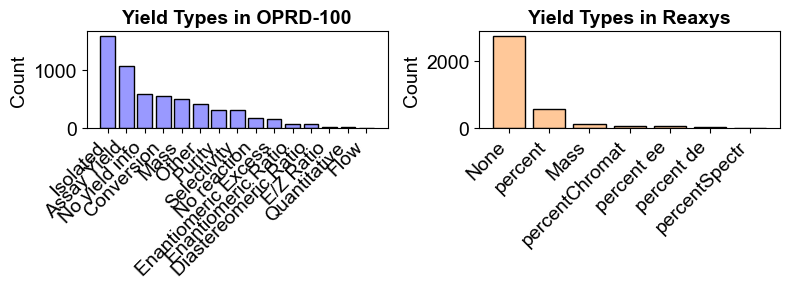

In [5]:
def json_to_dict(file_path):
    """
    Reads a JSON file and converts it to a dictionary.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"The file {file_path} does not exist.")

    with open(file_path, 'r') as file:
        data = json.load(file)
    return data

# Load OPRD-100 dataset
oprd_100_data = json_to_dict("../data/OPRD-100.json")
print(f"Loaded {len(oprd_100_data)} reactions from OPRD-100 dataset")

def json_yield_counts(data, summarize=True, final_step_only=True):
    counts_dict = {
        'Isolated': 0, 'Flow': 0, 'Conversion wrt SM': 0, 'Assay Yield': 0,
        'Selectivity': 0, 'er': 0, 'er R:S': 0, 'er S:R': 0,
        'ee': 0, 'ee (R)': 0, 'ee (S)': 0, 'dr': 0, 'E:Z': 0, 'Z:E': 0,
        'Mass': 0, 'Quantitative': 0, 'No reaction': 0, 'Purity': 0, 'other': 0,
        'No yield info': 0,
    }
    summarized_mapping = {
        'Isolated': 'Isolated', 'Flow': 'Flow',
        'Conversion wrt SM': 'Conversion', 'Assay Yield': 'Assay Yield',
        'Selectivity': 'Selectivity',
        'er': 'Enantiomeric Ratio', 'er R:S': 'Enantiomeric Ratio', 'er S:R': 'Enantiomeric Ratio',
        'ee': 'Enantiomeric Excess', 'ee (R)': 'Enantiomeric Excess', 'ee (S)': 'Enantiomeric Excess',
        'dr': 'Diastereomeric Ratio',
        'E:Z': 'E/Z Ratio', 'Z:E': 'E/Z Ratio',
        'Mass': 'Mass', 'Quantitative': 'Quantitative', 'No reaction': 'No reaction',
        'Purity': 'Purity', 'other': 'Other', 'No yield info': 'No yield info',
    }
    if summarize:
        counts_dict = {v: 0 for v in sorted(set(summarized_mapping.values()))}

    purity_type_counts = defaultdict(int)

    for entry in data:
        steps = entry.get("Steps", []) or []
        if not steps:
            continue
        steps_iter = [steps[-1]] if final_step_only else steps
        for step in steps_iter:
            y = step.get("Yield", {}) or {}
            if not isinstance(y, dict):
                continue

            # Purity type counted separately
            ptype = y.get("Purity type")
            if _has_value(ptype):
                for pt in ptype if isinstance(ptype, list) else [ptype]:
                    if _has_value(pt):
                        purity_type_counts[pt] += 1

            # Count occurrences of yield types
            has_yield_info = False
            for k, v in y.items():
                if k == "Purity type":
                    continue
                if _has_value(v):
                    has_yield_info = True
                    target = summarized_mapping.get(k, k) if summarize else k
                    if isinstance(v, list):
                        for i in v:
                            if _has_value(i):
                                counts_dict[target] += 1
                    else:
                        counts_dict[target] += 1
            if not has_yield_info:
                counts_dict["No yield info"] += 1

    return counts_dict, dict(purity_type_counts)

yield_type_counts, purity_counts = json_yield_counts(oprd_100_data, summarize=True, final_step_only=True)

yield_type_counts = dict(sorted(yield_type_counts.items(), key=lambda item: item[1], reverse=True))
# Read in the reaxys data into a dataframe
rde = ReaxysDataExtractor("../data/Reaxys_data/reaxys_100_articles_data.xml")
reaxys_data = rde.extract_reaction_data()
reaxys_df = pd.DataFrame(reaxys_data)
# Isolate the yields
reaxys_df["Yields"] = reaxys_df["Yields"].astype(str).str.replace("{", "").str.replace("}", "").str.replace("'", "")
reaxys_df["Yield Other"] = reaxys_df["Yield Other"].astype(str).str.replace("{", "").str.replace("}", "").str.replace("'", "")
reaxys_yield_data = reaxys_df["Yields"].to_list()
reaxys_yield_other = reaxys_df["Yield Other"].to_list()
# flatten both lists by splitting on ", "
reaxys_yield_data = [y for sublist in reaxys_yield_data for y in sublist.split(", ")]
reaxys_yield_other = [y for sublist in reaxys_yield_other for y in sublist.split(", ")]
# remove any None values
reaxys_yield_data = [y for y in reaxys_yield_data if y is not None]
reaxys_yield_other = [y for y in reaxys_yield_other if y is not None]
# combine the two lists for counting
reaxys_yield_data.extend([i for i in reaxys_yield_other if i != 'None'])
# Convert to a counts dictionary
reaxys_yield_counts = defaultdict(int)
for y in reaxys_yield_data:
    # remove extra characters
    y = re.sub(r">|<|=|~|\.", "", y)
    # remove any numbers with regex
    y = re.sub(r'\d+', '', y)
    # remoce Ca
    y = y.replace("Ca", "").replace("ca", "")
    # strip whitespace
    y = y.strip()
    if y in ["mg", "g", "kg"]:
        y = "Mass"
    reaxys_yield_counts[y] += 1
reaxys_yield_counts = dict(reaxys_yield_counts)

# sort the dictionares by descending order
yield_type_counts = dict(sorted(yield_type_counts.items(), key=lambda item: item[1], reverse=True))
reaxys_yield_counts = dict(sorted(reaxys_yield_counts.items(), key=lambda item: item[1], reverse=True))



plot = Plot(n_rows=1, n_cols=2, figsize=(8,3), title_fontdict=title_fontdict, label_fontdict=label_fontdict, tick_fontdict=tick_fontdict, legend_fontdict=legend_fontdict)

plot.add_bar(0, 0, list(yield_type_counts.keys()),
            yield_type_counts.values(),
            rotation=45,
            colour="blue",alpha=0.4,
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            title="Yield Types in OPRD-100",
            y_label="Count")
plot.add_bar(0, 1, list(reaxys_yield_counts.keys()),
            reaxys_yield_counts.values(),
            rotation=45,
            colour="#FF7701",alpha=0.4,
            bar_edgecolor=["black"], bar_edgewidth=[1.0],y_label="Count",
            title="Yield Types in Reaxys",)

plot.plot(

    savefig=True,
    filepath=filepath + "yield_types_reaxys_comparison.png"
    )

## 2. Yield Type Comparison

Analyze the types of yield metrics reported in both datasets (isolated, assay, conversion, enantiomeric excess, diastereomeric ratio, etc.).

[21:03:03] WARNING: not removing hydrogen atom without neighbors
[21:03:03] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:03] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:03] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:03] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:03] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:04] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:04] Explicit valence for atom # 0 B, 4, is greater than permitted
[21:03:04] Warning: molecule is tagged as 2D, but at least one Z coordinate is not zero. Marking the mol as 3D.
[21:03:04]

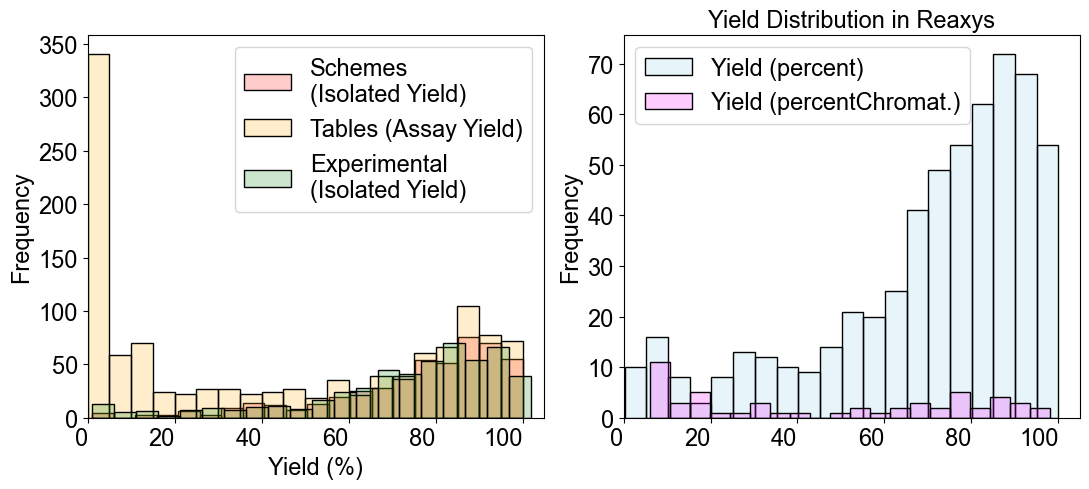

In [6]:
import math

def _to_float(x):
    """
    Try to convert a single token to float.
    Handles strings like '85', '85.0', '85%', '~85', '<90', '90 percent'.
    Returns None if conversion fails.
    """
    if isinstance(x, (int, float)) and not isinstance(x, bool):
        if isinstance(x, float) and math.isnan(x):
            return None
        return float(x)
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return None
        s = s.replace('%','')
        s = re.sub(r'^[<>=~]+','', s)           # remove leading symbols
        s = re.sub(r'\bpercent\b','', s, flags=re.I)
        s = s.strip()
        if not s:
            return None
        try:
            return float(s)
        except ValueError:
            return None
    return None

def _extract_masses_grams(val):
    """
    Extract all masses from val (string or iterable) and convert to grams.
    Supports patterns like:
      '5 mg', '0.25 g', '2 kg', '5-10 mg', '5 to 7 mg', ['5 mg','250 mg']
    Prioritizes matching units in order: mg, kg, then g.
    Returns list of floats (grams).
    """
    results = []

    def convert(num, unit):
        num = float(num)
        u = unit.lower()
        if u == 'mg':
            return num / 1000.0
        if u == 'kg':
            return num * 1000.0
        return num  # grams

    range_pattern = re.compile(
        r'(?P<n1>\d+(?:\.\d*)?)\s*(?:-|to)\s*(?P<n2>\d+(?:\.\d*)?)\s*(?P<u>mg|kg|g)\b',
        flags=re.I
    )
    pair_pattern = re.compile(
        r'(?P<n>\d+(?:\.\d*)?)\s*(?P<u>mg|kg|g)\b',
        flags=re.I
    )

    def parse_string(s):
        s = s.strip()
        if not s:
            return
        local = []
        # Ranges
        for m in range_pattern.finditer(s):
            local.append(convert(m.group('n1'), m.group('u')))
            local.append(convert(m.group('n2'), m.group('u')))
        # Singles (avoid double counting: remove matched ranges first by masking them)
        # Simple approach: still run; we will dedupe later.
        for m in pair_pattern.finditer(s):
            local.append(convert(m.group('n'), m.group('u')))
        # Prioritize mg, then kg, then g (stable sort by a rank)
        rank = {'mg':0, 'kg':1, 'g':2}
        local_sorted = sorted(local, key=lambda x: x)  # numeric sort not strictly needed
        results.extend(local_sorted)

    if isinstance(val, (list, tuple, set)):
        for item in val:
            if isinstance(item, (list, tuple, set)):
                for sub in item:
                    if isinstance(sub, str):
                        parse_string(sub)
                    elif isinstance(sub, (int, float)) and not (isinstance(sub, float) and math.isnan(sub)):
                        results.append(float(sub))
            elif isinstance(item, str):
                parse_string(item)
            elif isinstance(item, (int, float)) and not (isinstance(item, float) and math.isnan(item)):
                results.append(float(item))
    elif isinstance(val, (int, float)) and not (isinstance(val, float) and math.isnan(val)):
        results.append(float(val))
    elif isinstance(val, str):
        parse_string(val)

    # Deduplicate while preserving insertion order
    seen = set()
    out = []
    for x in results:
        if x not in seen:
            seen.add(x)
            out.append(x)
    return out

def json_yield_data(data, collect_by_location=False, data_locations: list=None,
                    summarize=True, final_step_only=True):
    summarized_mapping = {
        'Isolated': 'Isolated',
        'Conversion wrt SM': 'Conversion',
        'Assay Yield': 'Assay Yield',
        'ee': 'Enantiomeric Excess',
        'ee (R)': 'Enantiomeric Excess',
        'ee (S)': 'Enantiomeric Excess',
        'Mass': 'Mass',
        'Purity': 'Purity'
    }
    counts_dict = {v: [] for v in sorted(set(summarized_mapping.values()))}

    for entry in data:
        if collect_by_location:
            loc = entry.get("Location")
            # Location may be dict or string; attempt safe extraction
            loc_type = ""
            if isinstance(loc, dict):
                t = loc.get("Type")
                if isinstance(t, (list, tuple)):
                    loc_type = " ".join(str(x) for x in t)
                elif isinstance(t, str):
                    loc_type = t
            elif isinstance(loc, str):
                loc_type = loc
            # excklude if not matching data locations
            if data_locations:
                if data_locations == ["Table"]:
                    # Special case: match 'table' in location type
                    if not re.search(r'\btable\b', loc_type, flags=re.I):
                        continue
                else:
                    if not any(dl.lower().strip() == loc_type.lower().strip() for dl in data_locations):
                        continue

        steps = entry.get("Steps", []) or []
        if not steps:
            continue
        step_list = [steps[-1]] if final_step_only else steps

        for step in step_list:
            y = step.get("Yield", {}) or {}
            if not isinstance(y, dict):
                continue

            for k, v in y.items():
                if not _has_value(v):
                    continue

                # Mass
                if k == "Mass":
                    masses = _extract_masses_grams(v)
                    if masses:
                        counts_dict["Mass"].extend(masses)
                    continue

                # Quantitative / No reaction shortcut
                if k == "Quantitative":
                    counts_dict["Assay Yield"].append(100.0)
                    continue
                if k == "No reaction":
                    counts_dict["Assay Yield"].append(0.0)
                    continue

                target = summarized_mapping.get(k)
                if target and target in counts_dict and target != "Mass":
                    if isinstance(v, (list, tuple, set)):
                        for item in v:
                            f = _to_float(item)
                            if f is not None:
                                counts_dict[target].append(f)
                    else:
                        f = _to_float(v)
                        if f is not None:
                            counts_dict[target].append(f)

    return counts_dict

#############Collect OPRD-100 yield data by location#############
yields_table = json_yield_data(oprd_100_data, summarize=True, collect_by_location=True, data_locations=["Table"])
yields_schemes = json_yield_data(oprd_100_data, summarize=True, collect_by_location=True, data_locations=["Scheme"])
yields_experimental = json_yield_data(oprd_100_data, summarize=True, collect_by_location=True, data_locations=["Experimental"])
################### Collect Reaxys yield data ###################
# Read in the reaxys data into a dataframe
rde = ReaxysDataExtractor("../data/Reaxys_data/reaxys_100_articles_data.xml")
reaxys_data = rde.extract_reaction_data()
reaxys_df = pd.DataFrame(reaxys_data)

# Normalize the Yields column to a plain string (remove braces/quotes)
reaxys_df["Yields"] = (
    reaxys_df["Yields"]
    .astype(str)
    .str.replace("{", "", regex=False)
    .str.replace("}", "", regex=False)
    .str.replace("'", "", regex=False)
)

# Flatten to a list of individual yield tokens
reaxys_yield_tokens = reaxys_df["Yields"].tolist()
reaxys_yield_tokens = [tok for row in reaxys_yield_tokens for tok in row.split(", ") if tok]

# Split into raw buckets:
#  - percent: contains 'percent' but NOT 'percentChromat'
#  - percentChromat: contains 'percentChromat' (case-insensitive, punctuation-tolerant)
percent_chromat_raw = [
    y for y in reaxys_yield_tokens
    if re.search(r'percentchromat', y, flags=re.I)
]
percent_raw = [
    y for y in reaxys_yield_tokens
    if re.search(r'\bpercent\b', y, flags=re.I) and not re.search(r'percentchromat', y, flags=re.I)
]
def _extract_percent_numbers(raw_list):
    vals = []
    for item in raw_list:
        # Remove everything except digits, dot, and separators, then find numbers
        nums = re.findall(r'\d+(?:\.\d+)?', item)
        for n in nums:
            try:
                f = float(n)
                if 0 <= f <= 100:
                    vals.append(f)
            except ValueError:
                continue
    return vals
percent_values = _extract_percent_numbers(percent_raw)
percent_chromat_values = _extract_percent_numbers(percent_chromat_raw)

# Plot the yield distributions
plot = Plot(n_rows=1, n_cols=2, figsize=(11,5), title_fontdict={'fontsize':17}, label_fontdict={'fontsize':17}, tick_fontdict={'fontsize':17}, legend_fontdict={'size':17}, shared_title="", shared_title_fontdict={'fontsize': 14, 'fontweight': 'bold'})

plot.add_hist(0, 0, 
            data =  yields_schemes["Isolated"],
            bins=20,
            rotation=0,
            colour="red",alpha=0.2,
            label="Schemes\n(Isolated Yield)",
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            y_label="Frequency",x_label="Yield (%)")

plot.add_hist(0, 0, 
            data = yields_table["Assay Yield"],
            bins=20,
            rotation=0,
            colour="orange",alpha=0.2,
            label="Tables (Assay Yield)",
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            y_label="Frequency",x_label="Yield (%)", overlay=True)

plot.add_hist(0, 0, 
            data = yields_experimental["Isolated"],
            bins=20,
            rotation=0,
            colour="green",alpha=0.2,
            label="Experimental\n(Isolated Yield)",
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            x_label="Yield (%)",
            title="",
            y_label="Frequency", overlay=True,)

plot.add_hist(0, 1, 
            data = percent_values,
            bins=20,
            rotation=0,
            colour="skyblue",alpha=0.2,
            label="Yield (percent)",
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            title="Yield Distribution in Reaxys",
            y_label="Frequency",)

plot.add_hist(0, 1, 
            data = percent_chromat_values,
            bins=20,
            rotation=0,
            colour="magenta",alpha=0.2,
            label="Yield (percentChromat.)",
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            title="Yield Distribution in Reaxys",
            y_label="Frequency", overlay=True,)

plot.plot(
    savefig=True,
    filepath=filepath + "OPRD-100_yield_dist_reaxys_comparison.png",
)


## 3. Yield Distribution Analysis

Compare numerical yield value distributions across different data locations (schemes, tables, experimental sections).

In [7]:
# Where do the unique molecules and edges come from in our dataset?
from reaction_networks import ReactionNetworkGenerator
import pandas as pd
from rdkit import Chem
from collections import defaultdict
from StereoChem import CheckStereochemistry

def remove_stereo(smiles):
    mol = Chem.MolFromSmiles(smiles)
    Chem.RemoveStereochemistry(mol)
    return Chem.MolToInchiKey(mol)

filepath = "/mnt/c/Users/GHodg/OneDrive - University of Leeds (1)/Bao Nguyen's files - OPRD_data_2025/images/"
df = pd.read_excel("../data/OPRD-100.xlsx")
df = df[df["Reference"]!="op400219y"] # remove the article which is not in reaxys
doi_list = [i for i in df["Reference"].unique().tolist()]
# Loop through the DOI's and generate reaction networks
locs_list = []
edge_locs_list = []
counts_over_thresh = []
stereo_conflicts = []
mol_stereo_differences = []
for doi in doi_list:
    print(f"Processing DOI: {doi}")
    rg = ReactionNetworkGenerator(
    dataset1_path="../data/OPRD-100.xlsx",
    dataset2_path="../data/Reaxys_data/reaxys_100_articles_data.xml",
    doi=doi,
    dataset1_name="OPRD-100",
    dataset2_name="Reaxys Dataset",
    )
    rg.build_graph_from_nodes_edges(include_connected=True)
    node_dict = rg.get_common_and_unique_nodes(
    )
    count_dict = rg.count_common_and_different_nodes_edges()
    num_invalid_reactions = rg.num_invalid_reactions
    reaxys_mols = count_dict["nodes_by_dataset_and_shape"].get("Reaxys Dataset", {}).get("o", 0)
    reaxys_squares = count_dict["nodes_by_dataset_and_shape"].get("Reaxys Dataset", {}).get("s", 0)
    reaxys_triangles = count_dict["nodes_by_dataset_and_shape"].get("Reaxys Dataset", {}).get("^", 0)
    bnn_mols = count_dict["nodes_by_dataset_and_shape"].get("OPRD-100", {}).get("o", 0)
    bnn_squares = count_dict["nodes_by_dataset_and_shape"].get("OPRD-100", {}).get("s", 0)
    bnn_triangles = count_dict["nodes_by_dataset_and_shape"].get("OPRD-100", {}).get("^", 0)
    both_mols = count_dict["nodes_by_dataset_and_shape"].get("both", {}).get("o", 0)
    both_squares = count_dict["nodes_by_dataset_and_shape"].get("both", {}).get("s", 0)
    both_triangles = count_dict["nodes_by_dataset_and_shape"].get("both", {}).get("^", 0)
    common_edges = count_dict.get("common_edges", 0)
    reaxys_edges = count_dict.get("unique_edges_Reaxys Dataset", 0)
    bnn_edges = count_dict.get("unique_edges_OPRD-100", 0)
    #append the counts to a list
    counts = [doi, num_invalid_reactions, reaxys_mols, reaxys_squares, reaxys_triangles, bnn_mols, bnn_squares, bnn_triangles,
              both_mols, both_squares, both_triangles, common_edges, reaxys_edges, bnn_edges]
    #write the counts to a csv file
    with open("../output/reaxys_comparison_data/reaction_network_counts.csv", "a") as f:
        # If the file is empty, write the header
        if f.tell() == 0:
            f.write("DOI,Invalid Reactions,Reaxys_Molecules,Reaxys_Squares,Reaxys_Triangles,"
                    "OPRD-100_Molecules,OPRD-100_Squares,OPRD-100_Triangles,"
                    "Both_Molecules,Both_Squares,Both_Triangles,"
                    "Common_Edges,Reaxys_Edges,OPRD-100_Edges\n")
        # Write the counts
        f.write(",".join([str(i) for i in counts]) + "\n")

    res = rg.compute_unique_molecule_tanimoto(
    dataset_a="OPRD-100",
    dataset_b="Reaxys Dataset",
    threshold=0.8,
    remove_stereo=False,
    return_matrix=True,
    return_pairs=True,
    )
    counts = res["count"]
    counts_over_thresh.append(counts)

    locs = rg.get_unique_molecule_locations(dataset="OPRD-100")
    locs_list.append(locs)
    df_edges = rg.get_unique_edge_locations(dataset=rg.dataset1_name)
    edge_locs_list.append(df_edges)

    bnn_inchikey_to_smiles = defaultdict(set)
    for smi in node_dict["unique_nodes_OPRD-100"]:
        ikey = remove_stereo(smi)
        if ikey:
            bnn_inchikey_to_smiles[ikey].add(smi)

    reaxys_inchikey_to_smiles = defaultdict(set)
    for smi in node_dict["unique_nodes_Reaxys Dataset"]:
        ikey = remove_stereo(smi)
        if ikey:
            reaxys_inchikey_to_smiles[ikey].add(smi)

    bnn_set = set(bnn_inchikey_to_smiles.keys())
    reaxys_set = set(reaxys_inchikey_to_smiles.keys())
    shared = bnn_set & reaxys_set
    
    for key in shared:
        bnn_smiles = bnn_inchikey_to_smiles[key]
        bnn_mols = [Chem.MolFromSmiles(smi) for smi in bnn_smiles]
        bnn_stereo = set()
        for mol in bnn_mols:
            c = CheckStereochemistry(mol)
            centres = c.stereocentres
            bnn_stereo.update(centres)
        
        reaxys_smiles = reaxys_inchikey_to_smiles[key]
        # count stereocentres of each list of smiles
        reaxys_mols = [Chem.MolFromSmiles(smi) for smi in reaxys_smiles]
        reaxys_stereo = set()
        for mol in reaxys_mols:
            c = CheckStereochemistry(mol)
            centres = c.stereocentres
            reaxys_stereo.update(centres)
        # get the differences between the two sets
        union = bnn_stereo.union(reaxys_stereo)
        bnn_only = bnn_stereo - reaxys_stereo
        reaxys_only = reaxys_stereo - bnn_stereo
        if bnn_only or reaxys_only:
            mol_stereo_differences.append((doi, bnn_only, reaxys_only))

    shared_smiles = [dict[ikey] for dict in (bnn_inchikey_to_smiles, reaxys_inchikey_to_smiles) for ikey in shared]
    num_conflicts = len(shared)
    stereo_conflicts.append((doi, num_conflicts, shared_smiles))
# take the location information from the locs
all_locs = pd.concat(locs_list)
all_locs.to_csv("../output/reaxys_comparison_data/unique_node_locations.csv", index=False)

all_edge_locs = pd.concat(edge_locs_list)
all_edge_locs.to_csv("../output/reaxys_comparison_data/unique_edge_locations.csv", index=False)

counts_over_thresh = pd.DataFrame(counts_over_thresh)
counts_over_thresh.to_csv("../output/reaxys_comparison_data/unique_molecule_tanimoto_counts.csv", index=False)

stereo_conflicts_df = pd.DataFrame(stereo_conflicts, columns=["DOI", "Num_Stereo_Conflicts", "Shared_Smiles"])
stereo_conflicts_df.to_csv("../output/reaxys_comparison_data/stereo_conflicts.csv", index=False)

mol_stereo_differences_df = pd.DataFrame(mol_stereo_differences, columns=["DOI", "BNN_Only_Stereo", "Reaxys_Only_Stereo"])
mol_stereo_differences_df.to_csv("../output/reaxys_comparison_data/molecule_stereo_differences.csv", index=False)

import pandas as pd

# Get unique DOIs from OPRD-100 data (already loaded)
pairs_list = []
for doi in doi_list:
    print(f"Processing DOI: {doi}")
    rg = ReactionNetworkGenerator(
    dataset1_path="../data/OPRD-100.xlsx",
    dataset2_path="../data/Reaxys_data/reaxys_100_articles_data.xml",
    doi=doi,
    dataset1_name="OPRD-100",
    dataset2_name="Reaxys Dataset",
    )
    rg.build_graph_from_nodes_edges(include_connected=True)
    res = rg.compute_unique_molecule_tanimoto(
        return_matrix=False,
        return_pairs=True,
    )
    counts = res["count"]
    if counts > 5:
        print(f"DOI {doi} has {counts} pairs over the threshold.")
        pairs = res["pairs"]
        pairs_list.append(pairs)
        print(f"DOI {doi} has {counts} pairs over the threshold.")

/home/ghodgin/miniconda3/envs/oprd100/lib/python3.12/site-packages/rxnmapper/batched_mapper.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Processing DOI: acs.oprd.1c00456
Processing DOI: op980087x
Processing DOI: op700249f
Processing DOI: acs.oprd.2c00146
Processing DOI: acs.oprd.9b00192
Processing DOI: acs.oprd.9b00138
Processing DOI: acs.oprd.3c00189
Processing DOI: op000040n
Processing DOI: op000209x
Processing DOI: op0102159
Processing DOI: op0000733
Processing DOI: op9802125
Processing DOI: op8002213
Processing DOI: acs.oprd.7b00046
Processing DOI: op025504r
Processing DOI: op990074z
Processing DOI: acs.oprd.9b00194
Processing DOI: op700092n
Processing DOI: acs.oprd.0c00134
Processing DOI: acs.oprd.0c00149
Processing DOI: op050151s
Processing DOI: op800252w
Processing DOI: acs.oprd.0c00246
Processing DOI: acs.oprd.0c00281
Processing DOI: acs.oprd.1c00188
Processing DOI: acs.oprd.1c00244
Processing DOI: op700086d
Processing DOI: acs.oprd.8b00409
Processing DOI: acs.oprd.8b00428
Processing DOI: acs.oprd.2c00097
Processing DOI: acs.oprd.3c00184
Processing DOI: op700121y
Processing DOI: op5001226
Processing DOI: acs.opr

## 4. Reaction Network Analysis

Generate reaction networks for each article and compare:
- Unique molecules (nodes) in each dataset
- Unique reactions (edges) in each dataset
- Shared molecules and reactions
- Tanimoto similarity between unique molecules
- Stereochemistry conflicts

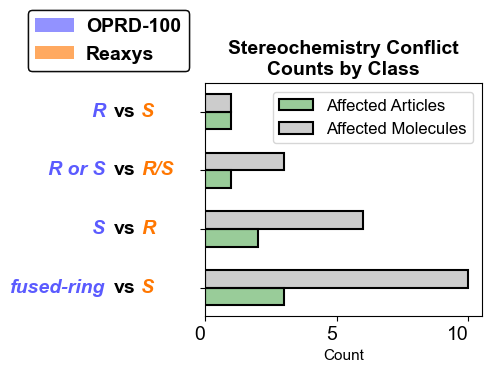

In [8]:
import ast
import pandas as pd
from PlottingFunctions import Plot
mol_stereo_differences_df = pd.read_csv("../output/reaxys_comparison_data/molecule_stereo_differences.csv")

_STATUSES = {"Specified", "Unspecified"}
_STYPES = {"Bond_Double", "Atom_Tetrahedral"}
_VALUES = {"Bond_Trans", "Bond_Cis", "E", "Z", "NoValue", "None", "Tet_CW", "Tet_CCW", "Fused ring"}

def _as_int_group(e):
    if isinstance(e, int):
        return ("int", e)
    if isinstance(e, (tuple, list)) and all(isinstance(x, int) for x in e):
        return ("tuple", tuple(e))
    return None

def _canon_center(center, stype):
    if isinstance(center, (tuple, list)):
        t = tuple(int(x) for x in center)
        if stype == "Bond_Double":
            return tuple(sorted(t))  # canonicalize pair order
        if len(t) == 1:
            return t[0]
        return t
    if isinstance(center, int):
        return center
    return None

def _canon_controls(ctrls):
    if ctrls is None:
        return tuple()
    if isinstance(ctrls, int):
        return (ctrls,)
    if isinstance(ctrls, (tuple, list)):
        ints = tuple(int(x) for x in ctrls if isinstance(x, int))
        return tuple(sorted(ints))
    return tuple()

def classify_conflict_dataset(stype, b_status, b_val, r_status, r_val, b_cip=None, r_cip=None):
    # Dataset-aware classification string, e.g. "Reaxys E vs BNN Z"
    r_lbl = _norm_label(stype, r_status, r_val, r_cip)
    b_lbl = _norm_label(stype, b_status, b_val, b_cip)

    if stype == "Bond_Double":
        ez = {"E", "Z", "cis", "trans"}
        if r_status == "Specified" and b_status == "Specified" and r_lbl in ez and b_lbl in ez and r_lbl != b_lbl:
            return f"Reaxys {r_lbl} vs BNN {b_lbl}"
        if r_status == "Specified" and _norm_label(stype, b_status, b_val, b_cip) == "unspecified":
            return "Reaxys E/Z vs BNN unspecified"
        if b_status == "Specified" and _norm_label(stype, r_status, r_val, r_cip) == "unspecified":
            return "BNN E/Z vs Reaxys unspecified"
        return "Other"

    if stype == "Atom_Tetrahedral":
        rs = {"R", "S"}
        if r_status == "Specified" and b_status == "Specified" and r_lbl in rs and b_lbl in rs and r_lbl != b_lbl:
            return f"Reaxys {r_lbl} vs BNN {b_lbl}"
        if r_status == "Specified" and b_lbl == "unspecified":
            return "Reaxys R/S vs BNN unspecified"
        if b_status == "Specified" and r_lbl == "unspecified":
            return "BNN R/S vs Reaxys unspecified"
        if (r_lbl == "fused ring" and b_lbl == "unspecified") or (b_lbl == "fused ring" and r_lbl == "unspecified"):
            return f"Reaxys {r_lbl} vs BNN {b_lbl}" if r_lbl == "fused ring" else f"Reaxys {r_lbl} vs BNN {b_lbl}"
        if r_lbl == "fused ring" and b_lbl in rs:
            return f"Reaxys fused ring vs BNN {b_lbl}"
        if b_lbl == "fused ring" and r_lbl in rs:
            return f"Reaxys {r_lbl} vs BNN fused ring"
        if r_lbl == "fused ring" and b_lbl == "fused ring":
            return "Reaxys fused ring vs BNN fused ring"
        return "Other"
    return "Other"

def _norm_label(stype, status, value, cip=None):
    # Prefer CIP labels when available
    if stype == "Bond_Double":
        if status == "Specified":
            if cip in {"E", "Z"}:
                return cip
            if value in {"E", "Z"}:
                return value
            if value == "Bond_Trans":
                return "trans"
            if value == "Bond_Cis":
                return "cis"
        if isinstance(value, str) and value.lower() in {"novalue", "none"}:
            return "unspecified"
        return (value or "unspecified")
    if stype == "Atom_Tetrahedral":
        if status == "Specified":
            if cip in {"R", "S"}:
                return cip
            if value == "Tet_CW":
                return "R"
            if value == "Tet_CCW":
                return "S"
        if value == "Fused ring":
            return "fused ring"
        if isinstance(value, str) and value.lower() in {"novalue", "none"}:
            return "unspecified"
        return (value or "unspecified")
    return (value or "unspecified")

def parse_stereo_cell(cell):
    """
    Handles sets like:
      {('SMILES', 8, (7,9,16), 'Unspecified', 'NoValue', 'Atom_Tetrahedral', ('CIP','R'))}
      {('SMILES', (3,4), (1,5,18), 'Specified', 'Bond_Trans', 'Bond_Double', ('CIP','E'))}
    and legacy shapes without CIP.
    Returns list of dicts: center, controls, status, value, stype, smiles, cip.
    """
    if cell is None or (isinstance(cell, float) and pd.isna(cell)):
        return []
    if isinstance(cell, (set, list, tuple)):
        raw = cell
    else:
        s = str(cell).strip()
        if not s or s == "set()":
            return []
        if s.startswith("frozenset(") and s.endswith(")"):
            s = s[len("frozenset("):-1]
        try:
            raw = ast.literal_eval(s)
        except Exception:
            return []
    if isinstance(raw, set):
        raw = list(raw)

    out = []
    for t in raw:
        if not isinstance(t, (list, tuple)):
            continue

        # Extract optional CIP pair at any position
        cip_label = None
        for e in t:
            if isinstance(e, (tuple, list)) and len(e) == 2 and e[0] == "CIP":
                cip_label = e[1]
                break

        # Collect strings and int-like groups
        strings = [e for e in t if isinstance(e, str)]
        stype = next((s for s in strings if s in _STYPES), None)
        status = next((s for s in strings if s in _STATUSES), None)
        value = next((s for s in strings if s in _VALUES), None)
        # First non-vocab string is treated as SMILES (works with SMILES at position 0)
        smiles = next((s for s in strings if s not in _STYPES | _STATUSES | _VALUES), None)

        int_groups = [g for g in (_as_int_group(e) for e in t) if g is not None]
        center = None
        controls = None

        # Heuristics:
        # - Tetrahedral: one int (center) + one 3-tuple (controls)
        # - Double bond: one 2-tuple (center) + one 3-tuple (controls)
        # Assign center first
        ints = [v for k, v in int_groups if k == "int"]
        tuples_ = [v for k, v in int_groups if k == "tuple"]

        # Prefer exact shapes
        if stype == "Atom_Tetrahedral":
            if ints:
                center = ints[0]
            if not center and any(len(v) == 1 for v in tuples_):
                center = next(v[0] for v in tuples_ if len(v) == 1)
            # controls as first 3+ tuple
            if any(len(v) >= 3 for v in tuples_):
                controls = next(v for v in tuples_ if len(v) >= 3)
        elif stype == "Bond_Double":
            # center as 2-tuple
            if any(len(v) == 2 for v in tuples_):
                center = next(v for v in tuples_ if len(v) == 2)
            # controls as first 3+ tuple
            if any(len(v) >= 3 for v in tuples_):
                controls = next(v for v in tuples_ if len(v) >= 3)

        # Fallback if stype missing or shapes unexpected
        if center is None:
            if ints:
                center = ints[0]
            elif tuples_:
                # Prefer len==2 then len==1 else first tuple
                center = next((v for v in tuples_ if len(v) == 2), None) or \
                         next((v for v in tuples_ if len(v) == 1), None) or \
                         tuples_[0]
                if isinstance(center, tuple) and len(center) == 1:
                    center = center[0]
        if controls is None:
            # Pick the first tuple of len>=3 that's not equal to center
            cset = set(center) if isinstance(center, (tuple, list)) else {center}
            cand = [v for v in tuples_ if len(v) >= 3 and not set(v) == cset]
            controls = cand[0] if cand else (tuples_[0] if tuples_ else tuple())

        center = _canon_center(center, stype)
        controls = _canon_controls(controls)

        out.append({
            "center": center,
            "controls": controls,
            "status": status if status else "Unspecified",
            "value": value if value else "NoValue",
            "stype": stype if stype else "Unknown",
            "smiles": smiles,
            "cip": cip_label,  # NEW
        })
    return out

def analyze_stereo_conflicts(df):
    """
    Compare BNN_Only_Stereo vs Reaxys_Only_Stereo row-wise.
    Returns one row per matched site (by canonical center, controls, stype).
    """
    records = []
    for _, row in df.iterrows():
        doi = row.get("DOI")
        b_list = parse_stereo_cell(row.get("BNN_Only_Stereo"))
        r_list = parse_stereo_cell(row.get("Reaxys_Only_Stereo"))

        def canon_key(d):
            return (_canon_center(d["center"], d["stype"]),
                    _canon_controls(d["controls"]),
                    d["stype"])

        b_map = {canon_key(d): d for d in b_list}
        r_map = {canon_key(d): d for d in r_list}

        keys = set(b_map.keys()) | set(r_map.keys())
        for key in keys:
            b = b_map.get(key)
            r = r_map.get(key)

            # Try match by (center, stype) if controls differ
            if b and not r:
                c, _, st = key
                candidates = [k for k in r_map if k[0] == c and k[2] == st]
                if candidates:
                    r = r_map[candidates[0]]
                    key = (c, r["controls"], st)
            elif r and not b:
                c, _, st = key
                candidates = [k for k in b_map if k[0] == c and k[2] == st]
                if candidates:
                    b = b_map[candidates[0]]
                    key = (c, b["controls"], st)

            center = key[0] if isinstance(key, tuple) else None
            controls = key[1] if isinstance(key, tuple) else None
            stype = key[2] if isinstance(key, tuple) else None

            b_status = b["status"] if b else None
            b_val = b["value"] if b else None
            r_status = r["status"] if r else None
            r_val = r["value"] if r else None
            b_smi = b.get("smiles") if b else None
            r_smi = r.get("smiles") if r else None
            b_cip = b.get("cip") if b else None
            r_cip = r.get("cip") if r else None

            def humanize(status, value, stype, cip=None):
                if stype == "Bond_Double":
                    base = "double bond"
                    if status == "Specified":
                        if cip in {"E", "Z"}:
                            return f"{cip} {base}"
                        vmap = {"Bond_Trans": "trans", "Bond_Cis": "cis", "E": "E", "Z": "Z"}
                        return f"{vmap.get(value, value)} {base}"
                    return "unspecified double bond" if value in ("NoValue", "None") else f"{(value or '').lower()} {base}"
                if stype == "Atom_Tetrahedral":
                    if status == "Specified":
                        if cip in {"R", "S"}:
                            return f"{cip} tetrahedral"
                        vmap = {"Tet_CW": "tetrahedral (CW)", "Tet_CCW": "tetrahedral (CCW)"}
                        return vmap.get(value, f"specified tetrahedral ({value})")
                    if isinstance(value, str) and value.lower() == "fused ring":
                        return "fused ring tetrahedral"
                    return "unspecified tetrahedral"
                return f"{status} {value} ({stype})"

            summary = ""
            if b and r:
                summary = f"{humanize(b_status, b_val, stype, b_cip)} vs {humanize(r_status, r_val, stype, r_cip)}"
                cls = classify_conflict_dataset(stype, b_status or "", b_val or "", r_status or "", r_val or "", b_cip=b_cip, r_cip=r_cip)
            elif b and not r:
                summary = f"{humanize(b_status, b_val, stype, b_cip)} (BNN only)"
                cls = "BNN only site"
            elif r and not b:
                summary = f"{humanize(r_status, r_val, stype, r_cip)} (Reaxys only)"
                cls = "Reaxys only site"
            else:
                cls = "Other"

            records.append({
                "DOI": doi,
                "center": center,
                "controls": controls,
                "stereo_type": stype,
                "BNN_status": b_status,
                "BNN_value": b_val,
                "BNN_smiles": b_smi,
                "BNN_CIP": b_cip,
                "Reaxys_status": r_status,
                "Reaxys_value": r_val,
                "Reaxys_smiles": r_smi,
                "Reaxys_CIP": r_cip,
                "classification": cls,
                "summary": summary,
            })
    return pd.DataFrame.from_records(records)

# Run on your dataframe
stereo_conflict_details = analyze_stereo_conflicts(mol_stereo_differences_df)
stereo_conflict_details.to_csv("../output/reaxys_comparison_data/stereo_conflict_details.csv", index=False)
# Optional: counts per DOI and overall
by_doi_counts = stereo_conflict_details.pivot_table(index="DOI", columns="classification", values="center", aggfunc="count", fill_value=0)
overall_counts = stereo_conflict_details["classification"].value_counts()

overall_counts_to_plot = overall_counts.loc[~overall_counts.index.isin(["Other", "Reaxys fused ring vs BNN fused ring", "Reaxys only site", "BNN only site"])]
summary = (
    stereo_conflict_details.loc[~stereo_conflict_details["classification"].isin(["Other", "Reaxys fused ring vs BNN fused ring", "Reaxys only site", "BNN only site"])]
    .groupby("classification", dropna=False)
    .agg(
        unique_dois=("DOI", "nunique"),
        unique_bnn_molecules=("BNN_smiles", "nunique"),
    )
    .sort_values(["unique_dois", "unique_bnn_molecules"], ascending=False)
)
full_summary = pd.merge(summary, overall_counts_to_plot.rename("Num_affected_centres"), left_index=True, right_index=True)
full_summary.sort_values(["Num_affected_centres"], ascending=False, inplace=True)

full_summary.to_csv("../output/reaxys_comparison_data/stereo_conflict_summary.csv")

# Plot the results
plot = Plot(n_rows=2, n_cols=2, figsize=(8, 6), title_fontdict={'fontsize': 14, 'fontweight': 'bold'}, label_fontdict={'fontsize': 11}, tick_fontdict={'fontsize': 14, 'fontweight': 'bold'}, legend_fontdict={'size': 12,})


categories = overall_counts_to_plot.index.str.replace(r'BNN', r'OPRD-100', regex=True)

# ['Reaxys S vs BNN fused ring', 'Reaxys R vs BNN S',
#        'BNN R/S vs Reaxys unspecified', 'BNN E/Z vs Reaxys unspecified',
#        'Reaxys R/S vs BNN unspecified', 'Reaxys fused ring vs BNN R',
#        'Reaxys fused ring vs BNN S', 'Reaxys E/Z vs BNN unspecified',
#        'Reaxys S vs BNN R']


['Reaxys S vs BNN fused ring',
 'Reaxys R vs BNN S',
 'BNN R/S vs Reaxys unspecified',
 'Reaxys S vs BNN R']

vs = ['vs','vs','vs','vs'
]
reaxys = [
'S',
 'R',
    "R/S",
 'S'
]

oprd = [
    'fused-ring',
    'S',
    "R or S",
    'R'
]


categories = [
    full_summary.loc[:, "unique_dois"].to_list(),
    full_summary.loc[:, "unique_bnn_molecules"].to_list(),
    #full_summary.loc[:, "Num_affected_centres"].to_list()
]



plot.add_horizontal_bar(
    0, 0,
    ["" for _ in range(len(full_summary))],#["" for _ in range(len(oprd))],
    categories,
    colour=["green", "grey", "gold"], alpha=[0.4, 0.4, 0.4],
    bar_labels=["Affected Articles", "Affected Molecules", "Affected Centres"],
    #bar_edgecolor=["black"], bar_edgewidth=[1.0, 1.0, 1.0],
    bar_height=0.3,
    title="Stereochemistry Conflict\nCounts by Class",
    x_label="Count",
    side_by_side=True
)

#One label per bar; x=-0.08 is outside left; y is bar index (data coords)
for i, lbl in enumerate(oprd):
    plot.add_textbox(
        0, 0, lbl,
        xy=(-0.36, i+0.15),
        fontsize=14, fontweight='bold', color='#5B5BFF',
        ha="right", va="center",
        coord="axes,data",  # x in axes fraction, y in data coords
        fontstyle="italic"
    )
for i, lbl in enumerate(vs):
    plot.add_textbox(
        0, 0, lbl,
        xy=(-0.25, i+0.15),
        fontsize=14, fontweight='bold', color='black',
        ha="right", va="center",
        coord="axes,data"  # x in axes fraction, y in data coords
    )
for i, lbl in enumerate(reaxys):
    plot.add_textbox(
        0, 0, lbl,
        xy=(-0.23, i+0.15),
        fontsize=14, fontweight='bold', color='#FF7701',
        ha="left", va="center", fontstyle="italic",
        coord="axes,data"  # x in axes fraction, y in data coords
    )

entries = [
    {'label': 'OPRD-100', 'color': 'blue', 'alpha': 0.4},
    {'label': 'Reaxys', 'color': '#FF7701', 'alpha': 0.6},
]
plot.add_figure_legend(
    entries,
    title=None,
    anchor=(0.15, 0.9075),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=1,
    label_fontsize=14,
    label_fontweight='bold'
)
filepath = "../output/reaxys_comparison_figures/"
plot.plot(
    savefig=True,
    filepath=filepath + "stereo_conflicts.png",
)

## 5. Stereochemistry Conflict Classification

Detailed analysis and classification of stereochemical differences between datasets, including:
- Identification of conflicting stereochemistry
- Classification by conflict type (R vs S, E vs Z, specified vs unspecified)
- Quantification of affected molecules and articles

In [9]:
full_summary

,unique_dois,unique_bnn_molecules,Num_affected_centres
classification,,,
Reaxys S vs BNN fused ring,3,10,19
Reaxys R vs BNN S,2,6,11
BNN R/S vs Reaxys unspecified,1,3,3
Reaxys S vs BNN R,1,1,1


## 6. Molecule Identity Classification

Classify unique molecules as potential intermediates or reagents by checking CAS number availability in PubChem.

In [10]:
# Intermediate node checking, followed by Reagent checker with pubchem

from reaction_networks import ReactionNetworkGenerator
from molecule_presence_checker import MoleculePresenceChecker
import pandas as pd
from collections import defaultdict
from rdkit import Chem



# Get unique DOIs from OPRD-100 data (already loaded)
# Loop through the DOI's and generate reaction networks
intermediate_node_counts = {
    "OPRD-100": 0,
    "Reaxys Dataset": 0
}

chk = MoleculePresenceChecker()

# Uniqueness sets (by InChIKey) and lists for downstream checks
inchi_key_check_oprd_100 = set()
oprd_smiles_to_check = []
inchi_key_check_reaxys = set()
reaxys_smiles_to_check = []

# New: SMILES -> count dictionaries per dataset
oprd_smiles_counts = defaultdict(int)
reaxys_smiles_counts = defaultdict(int)

for doi in doi_list:
    rg = ReactionNetworkGenerator(
        dataset1_path="../data/OPRD-100.xlsx",
        dataset2_path="../data/Reaxys_data/reaxys_100_articles_data.xml",
        doi=doi,
        dataset1_name="OPRD-100",
        dataset2_name="Reaxys Dataset",
    )
    node_counts, node_list = rg.get_unique_molecules_between_shared(
        require_direct=False,
        enforce_edge_dataset_match=False,
        return_labels=True,
        return_dataset_counts=True
    )

    # Tally per-dataset totals (as before)
    reaxys_node_count = node_counts.get("Reaxys Dataset", 0)
    oprd_100_node_counts = node_counts.get("OPRD-100", 0)
    intermediate_node_counts["Reaxys Dataset"] += reaxys_node_count
    intermediate_node_counts["OPRD-100"] += oprd_100_node_counts

    # Get unique mols and their counts for each dataset
    node_dict = rg.get_common_and_unique_nodes(
    )
    oprd_100_unique_nodes = node_dict.get("unique_nodes_OPRD-100")
    reaxys_unique_nodes = node_dict.get("unique_nodes_Reaxys Dataset")
    for dataset, smiles in node_dict.items():
        if dataset == "unique_nodes_OPRD-100":
            if smiles:
                for smi in smiles:
                    oprd_smiles_counts[smi] += 1
                    mol = Chem.MolFromSmiles(smi)
                    key = Chem.inchi.MolToInchiKey(mol)
                    # Maintain uniqueness for the list to check
                    if key and key not in inchi_key_check_oprd_100:
                        inchi_key_check_oprd_100.add(key)
                        oprd_smiles_to_check.append(smi)
        if dataset == "unique_nodes_Reaxys Dataset":
            if smiles:
                for smi in smiles:
                    reaxys_smiles_counts[smi] += 1
                    mol = Chem.MolFromSmiles(smi)
                    key = Chem.inchi.MolToInchiKey(mol)
                    # Maintain uniqueness for the list to check
                    if key and key not in inchi_key_check_reaxys:
                        inchi_key_check_reaxys.add(key)
                        reaxys_smiles_to_check.append(smi)

# Convert defaultdicts to dicts for downstream use
oprd_smiles_counts = dict(oprd_smiles_counts)
reaxys_smiles_counts = dict(reaxys_smiles_counts)


In [11]:
oprd_availability = chk.check(list(oprd_smiles_counts.keys()))
reaxys_availability = chk.check(list(reaxys_smiles_counts.keys()))

/home/ghodgin/green_sol_ai/validation/data_analysis/src/molecule_presence_checker.py:163: PubChemPyDeprecationWarning: isomeric_smiles is deprecated: Use smiles instead
  cs = getattr(c, "isomeric_smiles", None) if prefer_isomeric else getattr(c, "canonical_smiles", None)


KeyboardInterrupt: 

In [12]:
oprd_availability_results = pd.DataFrame.from_dict(oprd_availability, orient="index").rename_axis("smiles").reset_index()
oprd_availability_results.to_csv("../output/reaxys_comparison_data/OPRD-100_cas_check.csv", index=False)
reaxys_availability_results = pd.DataFrame.from_dict(reaxys_availability, orient="index").rename_axis("smiles").reset_index()
reaxys_availability_results.to_csv("../output/reaxys_comparison_data/Reaxys_cas_check.csv", index=False)

NameError: name 'reaxys_availability' is not defined

### Visualize Molecule Classification Results

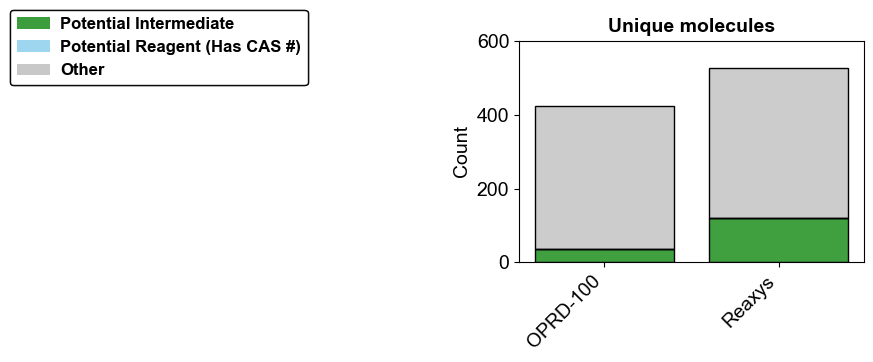

In [14]:

# Read in the data
import pandas as pd
oprd_availability_results = pd.read_csv("../output/reaxys_comparison_data/OPRD-100_cas_check.csv")
oprd_has_cas = len(oprd_availability_results[oprd_availability_results.loc[:,"Has_CAS"]==True])
reaxys_availability_results = pd.read_csv("../output/reaxys_comparison_data/Reaxys_cas_check.csv")
reaxys_has_cas = len(reaxys_availability_results[reaxys_availability_results.loc[:,"Has_CAS"]==True])
intermediate_node_counts = {'OPRD-100': 36, 'Reaxys Dataset': 120}

other_oprd = len(oprd_availability_results) - oprd_has_cas - 36
other_reaxys = len(reaxys_availability_results) - reaxys_has_cas - 120
# Plot the results
from PlottingFunctions import Plot
# Plot the results
plot = Plot(n_rows=2, n_cols=2, figsize=(8, 6), title_fontdict={'fontsize': 14, 'fontweight': 'bold'}, label_fontdict={'fontsize': 14}, tick_fontdict={'fontsize': 14, 'fontweight': 'bold'}, legend_fontdict={'size': 12,})

entries = [
    {'label': 'Potential Intermediate', 'color': 'green', 'alpha': 0.75},
    {'label': 'Potential Reagent (Has CAS #)', 'color': 'skyblue', 'alpha': 0.8},
    {'label': 'Other', 'color': 'grey', 'alpha': 0.4},
]
plot.add_figure_legend(
    entries,
    title=None,
    anchor=(0.1, 0.85),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=1,
    label_fontsize=12,
    label_fontweight='bold'
)
plot.add_stacked_bar(0, 1, 
            ["OPRD-100", "Reaxys"],
            [list(intermediate_node_counts.values()), [oprd_has_cas, reaxys_has_cas], [other_oprd, other_reaxys]],
            rotation=45,
            colours=["green", "skyblue", "grey"],
            alpha=[0.75, 0.8, 0.4],
            #bar_labels = ["Potential Intermediate", "Potential Reagent", "Other"],
            bar_edgecolor="black", bar_edgewidth=1.0,
            title="Unique molecules",
            ymax=601,
            y_label="Count")
plot.plot(
    savefig=True,
    filepath=filepath + "molecule_identities.png",
)

## 7. Summary Visualizations

Generate comprehensive summary plots showing:
- Molecule overlaps between datasets (Venn diagrams)
- Location distributions for unique molecules
- Tanimoto similarity distributions
- Stereochemistry conflict distributions

/home/ghodgin/miniconda3/envs/oprd100/lib/python3.12/site-packages/matplotlib_venn/_venn2.py:162: UserWarning: normalize_to is deprecated. Please use layout_algorithm=matplotlib_venn.layout.venn2.DefaultLayoutAlgorithm(normalize_to) instead.
  warnings.warn(


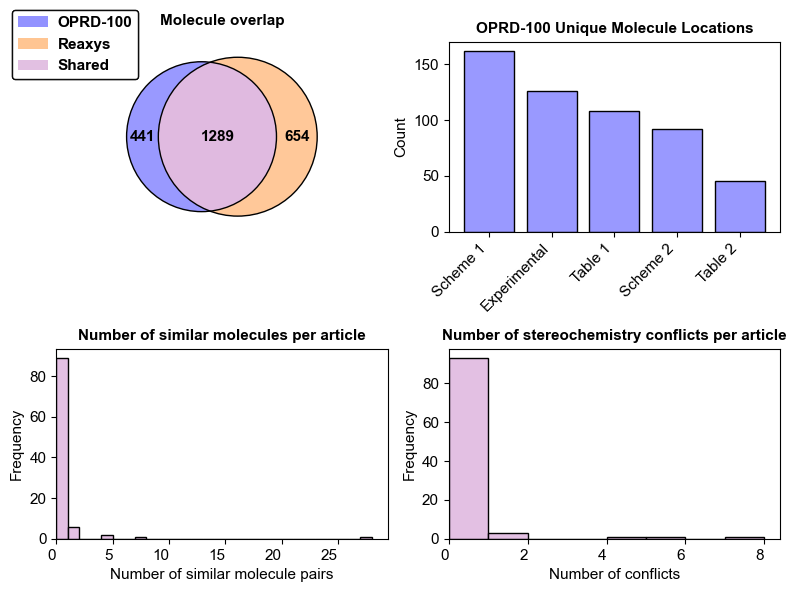

In [15]:
from PlottingFunctions import Plot
import re
import pandas as pd

all_locs = pd.read_csv("../output/reaxys_comparison_data/unique_node_locations.csv")
node_location_data = all_locs["Locations"].to_list()
# flatten the list on ", "
node_location_data = [item for sublist in node_location_data for item in sublist.split(", ")]
all_edge_locs = pd.read_csv("../output/reaxys_comparison_data/unique_edge_locations.csv")
edge_location_data = all_edge_locs["Locations"].to_list()
# flatten the list on ", "
edge_location_data = [item for sublist in edge_location_data for item in sublist.split(", ")]
# strip entry information from location data
node_location_data = [i for i in node_location_data if "entry" not in i and "eq" not in i]
node_location_data = [i[0].upper() + i[1:] for i in node_location_data]
# get unique value counts in location data
node_location_counts = pd.Series(node_location_data).value_counts()[:5]
# Plot the results
plot = Plot(n_rows=2, n_cols=2, figsize=(8, 6), title_fontdict={'fontsize': 11, 'fontweight': 'bold'}, label_fontdict={'fontsize': 11,}, tick_fontdict={'fontsize': 11, 'fontweight': 'bold'}, legend_fontdict={'size': 11,})

counts_df = pd.read_csv("../output/reaxys_comparison_data/reaction_network_counts.csv")
counts_df = counts_df[counts_df["DOI"] != "op400219y"]

title_fontdict={'fontsize': 25, 'fontweight': 'bold'}
bnn_unique = int(counts_df['OPRD-100_Molecules'].sum())
reaxys_unique = int(counts_df['Reaxys_Molecules'].sum())
shared = int(counts_df['Both_Molecules'].sum())

plot.add_venn2(
    0, 0,
    subsets=(bnn_unique, reaxys_unique, shared),
    set_labels=('', ''),#('OPRD-100', 'Reaxys'),
    set_colors=('blue', '#FF7701'),
    alpha=0.4,
    title='',
    circle_color='black', circle_alpha=1.0, circle_lw=1.0,
    set_label_fontsize=11, subset_fontsize=11,
    set_label_fontweight='normal', subset_fontweight='bold'
)
plot.add_textbox(0, 0, "Molecule overlap", xy=(0.5, 1.11), fontsize=11, fontweight='bold')
entries = [
    {'label': 'OPRD-100', 'color': 'blue', 'alpha': 0.4},
    {'label': 'Reaxys', 'color': '#FF7701', 'alpha': 0.4},
    {'label': 'Shared', 'color': '#E0BAE0', 'alpha': 0.9},
]
plot.add_figure_legend(
    entries,
    title=None,
    anchor=(0.1, 0.85),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=1,
    label_fontsize=11,
    label_fontweight='bold'
)
plot.add_bar(0, 1, node_location_counts.index,
            node_location_counts.values,
            rotation=45,
            colour="blue",alpha=0.4,
            bar_edgecolor=["black"], bar_edgewidth=[1.0],
            title="OPRD-100 Unique Molecule Locations",
            y_label="Count")
counts = pd.read_csv("../output/reaxys_comparison_data/unique_molecule_tanimoto_counts.csv")
counts_data = counts.iloc[:,0].to_list()
plot.add_hist(1,0,colspan=1,
    data=counts_data,
    bins=28,
    colour="#E0BAE0",
    bar_edgecolor="black", bar_edgewidth=1.0,
    alpha=0.9,    title="Number of similar molecules per article",
    x_label="Number of similar molecule pairs",
    y_label="Frequency"
)
stereo_conflicts_df = pd.read_csv("../output/reaxys_comparison_data/stereo_conflicts.csv")
plot.add_hist(1,1,colspan=1,
    data=stereo_conflicts_df["Num_Stereo_Conflicts"].to_list(),
    bins=8,
    colour="#E0BAE0",
    bar_edgecolor="black", bar_edgewidth=1.0,
    alpha=0.9,    title="Number of stereochemistry conflicts per article",
    x_label="Number of conflicts",
    y_label="Frequency"
)
plot.plot(
    savefig=True,
    filepath=filepath + "molecule_venn_and_location_plots_new.png",
)

In [16]:
# Check how many articles have stereochemistry conflicts
stereo_conflicts_df = pd.read_csv("../output/reaxys_comparison_data/stereo_conflicts.csv")

stereo_conflicts_df[stereo_conflicts_df["Num_Stereo_Conflicts"]>0]

,DOI,Num_Stereo_Conflicts,Shared_Smiles
3,acs.oprd.2c00146,1,"[{'C[C@@H]1OC(O)[C@@H](O)[C@H](O)[C@@H]1O'}, {..."
13,acs.oprd.7b00046,5,[{'O=C(O)[C@H]1c2ccccc2C(=O)N(CC(F)(F)F)[C@@H]...
32,op5001226,8,[{'CCC(=O)O[C@]1(C(=O)SCC(=O)O)[C@H](C)CC2C3C[...
39,acs.oprd.7b00153,1,[{'C[C@@H]1CCC2[C@@H](C)C(=O)O[C@@H]3O[C@@]4(C...
56,op034028h,4,"[{'CC(=O)NC[C@H](O)CCl'}, {'CC(=O)NC[C@H]1CO1'..."
87,op5003215,1,"[{'CCOC(=O)C[C@@H](O)c1ccccc1'}, {'CCOC(=O)C[C..."


### Edge (Reaction) Overlap Analysis

/home/ghodgin/miniconda3/envs/oprd100/lib/python3.12/site-packages/matplotlib_venn/_venn2.py:162: UserWarning: normalize_to is deprecated. Please use layout_algorithm=matplotlib_venn.layout.venn2.DefaultLayoutAlgorithm(normalize_to) instead.
  warnings.warn(


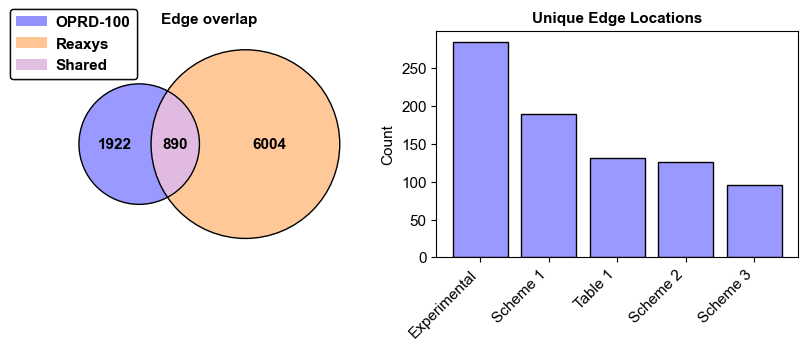

In [17]:
from PlottingFunctions import Plot
import re
import pandas as pd


all_locs = pd.read_csv("../output/reaxys_comparison_data/unique_node_locations.csv")
node_location_data = all_locs["Locations"].to_list()
# flatten the list on ", "
node_location_data = [item for sublist in node_location_data for item in sublist.split(", ")]
all_edge_locs = pd.read_csv("../output/reaxys_comparison_data/unique_edge_locations.csv")
edge_location_data = all_edge_locs["Locations"].to_list()
# flatten the list on ", "
edge_location_data = [item for sublist in edge_location_data for item in sublist.split(", ")]
edge_location_data = [i[0].upper() + i[1:] for i in edge_location_data]
# strip entry information from location data
node_location_data = [i for i in node_location_data if "entry" not in i and "eq" not in i]
node_location_data = [i[0].upper() + i[1:] for i in node_location_data]
# get unique value counts in location data
node_location_counts = pd.Series(node_location_data).value_counts()[:5]
edge_location_counts = pd.Series(edge_location_data).value_counts()[:5]
# Plot the results
plot = Plot(n_rows=2, n_cols=2, figsize=(8, 6), title_fontdict={'fontsize': 11, 'fontweight': 'bold'}, label_fontdict={'fontsize': 11,}, tick_fontdict={'fontsize': 11, 'fontweight': 'bold'}, legend_fontdict={'size': 11,})

counts_df = pd.read_csv("../output/reaxys_comparison_data/reaction_network_counts.csv")
counts_df = counts_df[counts_df["DOI"] != "op400219y"]

title_fontdict={'fontsize': 25, 'fontweight': 'bold'}
bnn_unique = int(counts_df['OPRD-100_Molecules'].sum())
reaxys_unique = int(counts_df['Reaxys_Molecules'].sum())
shared = int(counts_df['Both_Molecules'].sum())


bnn_unique_edges = int(counts_df['OPRD-100_Edges'].sum())
reaxys_unique_edges = int(counts_df['Reaxys_Edges'].sum())
shared_edges = int(counts_df['Common_Edges'].sum())
plot.add_venn2(
    0, 0,
    subsets=(bnn_unique_edges, reaxys_unique_edges, shared_edges),
    set_labels=('', ''),#('OPRD-100', 'Reaxys'),
    set_colors=('blue', '#FF7701'),
    alpha=0.4,
    title=None,
    circle_color='black', circle_alpha=1.0, circle_lw=1.0,
    set_label_fontsize=11, subset_fontsize=11,
    set_label_fontweight='normal', subset_fontweight='bold'
)
plot.add_textbox(0, 0, "Edge overlap", xy=(0.5, 1.05), fontsize=11, fontweight='bold')
entries = [
    {'label': 'OPRD-100', 'color': 'blue', 'alpha': 0.4},
    {'label': 'Reaxys', 'color': '#FF7701', 'alpha': 0.4},
    {'label': 'Shared', 'color': '#E0BAE0', 'alpha': 0.9},
]
plot.add_figure_legend(
    entries,
    title=None,
    anchor=(0.075, 0.85),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=1,
    label_fontsize=11,
    label_fontweight='bold'
)

plot.add_bar(0, 1, edge_location_counts.index,
            edge_location_counts.values,
            rotation=45,
            colour="blue", alpha=0.4,
            bar_edgecolor="black", bar_edgewidth=1.0,
            title="Unique Edge Locations",
            y_label="Count")

plot.plot(
    savefig=True,
    filepath=filepath + "edge_venn_and_location_plots.png",
)

### Combined Molecule and Edge Venn Diagrams

/home/ghodgin/miniconda3/envs/oprd100/lib/python3.12/site-packages/matplotlib_venn/_venn2.py:162: UserWarning: normalize_to is deprecated. Please use layout_algorithm=matplotlib_venn.layout.venn2.DefaultLayoutAlgorithm(normalize_to) instead.
  warnings.warn(


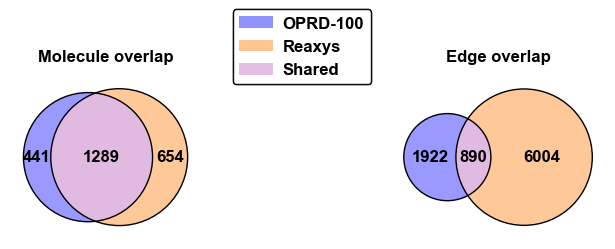

In [18]:
from PlottingFunctions import Plot
import re
import pandas as pd


all_locs = pd.read_csv("../output/reaxys_comparison_data/unique_node_locations.csv")
node_location_data = all_locs["Locations"].to_list()
# flatten the list on ", "
node_location_data = [item for sublist in node_location_data for item in sublist.split(", ")]
all_edge_locs = pd.read_csv("../output/reaxys_comparison_data/unique_edge_locations.csv")
edge_location_data = all_edge_locs["Locations"].to_list()
# flatten the list on ", "
edge_location_data = [item for sublist in edge_location_data for item in sublist.split(", ")]
# strip entry information from location data
node_location_data = [i for i in node_location_data if "entry" not in i and "eq" not in i]
node_location_data = [i[0].upper() + i[1:] for i in node_location_data]
# get unique value counts in location data
node_location_counts = pd.Series(node_location_data).value_counts()[:5]
# Plot the results
plot = Plot(n_rows=2, n_cols=2, figsize=(8, 4), title_fontdict={'fontsize': 12, 'fontweight': 'bold'}, label_fontdict={'fontsize': 12,}, tick_fontdict={'fontsize': 12, 'fontweight': 'bold'}, legend_fontdict={'size': 12,})

counts_df = pd.read_csv("../output/reaxys_comparison_data/reaction_network_counts.csv")
counts_df = counts_df[counts_df["DOI"] != "op400219y"]

title_fontdict={'fontsize': 25, 'fontweight': 'bold'}
bnn_unique = int(counts_df['OPRD-100_Molecules'].sum())
reaxys_unique = int(counts_df['Reaxys_Molecules'].sum())
shared = int(counts_df['Both_Molecules'].sum())

plot.add_venn2(
    0, 0,
    subsets=(bnn_unique, reaxys_unique, shared),
    set_labels=('', ''),#('OPRD-100', 'Reaxys'),
    set_colors=('blue', '#FF7701'),
    alpha=0.4,
    title='',
    circle_color='black', circle_alpha=1.0, circle_lw=1.0,
    set_label_fontsize=12, subset_fontsize=12,
    set_label_fontweight='normal', subset_fontweight='bold'
)
plot.add_textbox(0, 0, "Molecule overlap", xy=(0.5, 1.11), fontsize=12, fontweight='bold')
entries = [
    {'label': 'OPRD-100', 'color': 'blue', 'alpha': 0.4},
    {'label': 'Reaxys', 'color': '#FF7701', 'alpha': 0.4},
    {'label': 'Shared', 'color': '#E0BAE0', 'alpha': 0.9},
]
plot.add_figure_legend(
    entries,
    title=None,
    anchor=(0.5, 0.85),   # centered at bottom of the entire figure
    loc='lower center',
    frame=True,
    frame_facecolor='white',
    frame_alpha=0.9,
    frame_edgecolor='black',
    ncol=1,
    label_fontsize=12,
    label_fontweight='bold'
)

bnn_unique_edges = int(counts_df['OPRD-100_Edges'].sum())
reaxys_unique_edges = int(counts_df['Reaxys_Edges'].sum())
shared_edges = int(counts_df['Common_Edges'].sum())
plot.add_textbox(0, 1, "Edge overlap", xy=(0.5, 1.11), fontsize=12, fontweight='bold')
plot.add_venn2(
    0, 1,
    subsets=(bnn_unique_edges, reaxys_unique_edges, shared_edges),
    set_labels=('', ''),#('OPRD-100', 'Reaxys'),
    set_colors=('blue', '#FF7701'),
    alpha=0.4,
    title="",
    circle_color='black', circle_alpha=1.0, circle_lw=1.0,
    set_label_fontsize=12, subset_fontsize=12,
    set_label_fontweight='normal', subset_fontweight='bold'
)

plot.plot(
    savefig=True,
    filepath=filepath + "molecule_edge_venns.png",
)

## 8. Example Reaction Network Visualizations

Visualize specific reaction networks from individual articles to illustrate differences between OPRD-100 and Reaxys datasets.

### Example: Article op9802125 - Reaxys Network

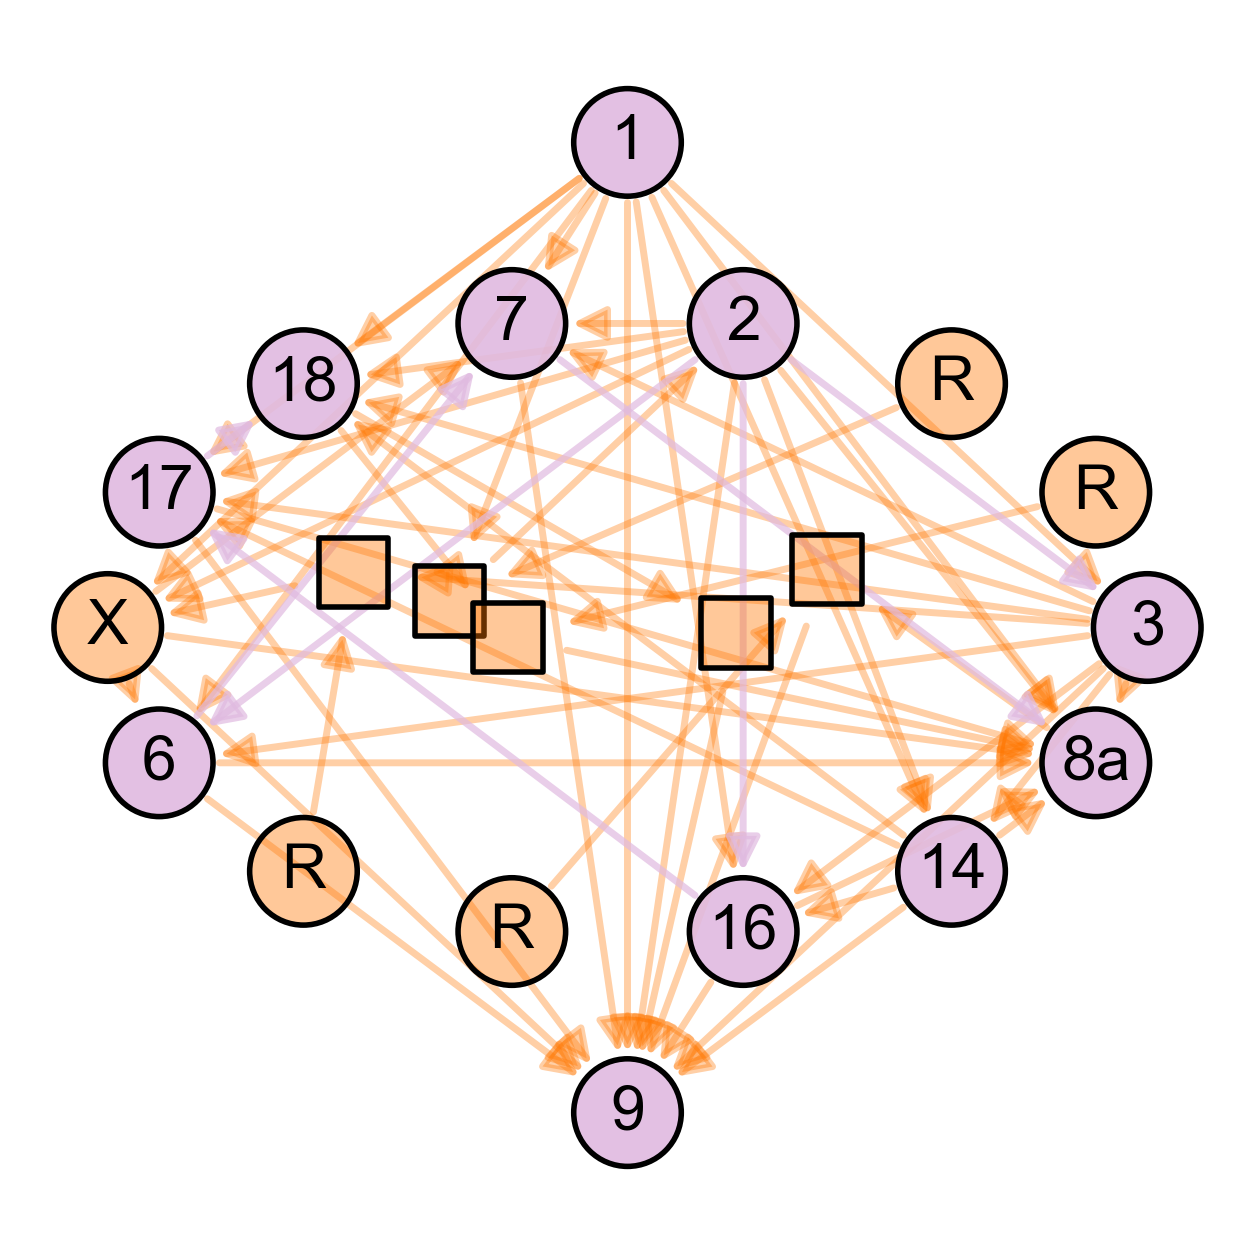

In [19]:
from reaction_networks import ReactionNetworkGenerator
# op9802125
rg = ReactionNetworkGenerator(
        dataset1_path="../data/OPRD-100.xlsx",
        dataset2_path="../data/Reaxys_data/reaxys_100_articles_data.xml",
        doi="op9802125",
        dataset1_name="OPRD-100",
        dataset2_name="Reaxys Dataset",
        mol_labels={
            "ClC1=C(C=C(S1)Cl)C(C)=O": "1",
            "ClC1=CC(C(C)=O)=C(S1)SCC2=CC=CC=C2":"2",
            "ClC1=CC(C(C)=O)=C(SCl)S1": "3",
            "ClC1=CC(C(C)=O)=C(S(Cl)(=O)=O)S1": "4",
            "ClC1=CC(C(C)=O)=C(S1)SNCCOC": "5",
            "ClC1=CC(C(C)=O)=C(S1)S(NCCOC)(=O)=O": "6",
            "ClC1=CC(C(CBr)=O)=C(S1)S(NCCOC)(=O)=O": "7",
            "ClC1=CC([C@H](O)CN2CCOC)=C(S1)S2(=O)=O": "8a",
            "O[C@@H](C1=C2SC(SCC3=CC=CC=C3)=C1)CN(CCOC)S2(=O)=O": "9",
            "O[C@@H](C1=C2SC(S(NC(C)(C)C)(=O)=O)=C1)CN(CCOC)S2(=O)=O": "10",
            "O[C@@H](C1=C2SC(S(N)(=O)=O)=C1)CN(CCOC)S2(=O)=O": "11a",
            "O[C@H](CN1CCOC)C2=C(S1(=O)=O)SC(S(=O)(N=C(C)OC)=O)=C2": "12",
            "COCCN1C[C@H](NCC)C2=C(S1(=O)=O)SC(S(=O)(N)=O)=C2": "13",
            "COCCNS(c1c(C(C)=O)cc(Cl)s1)=O": "X",
            "NSc1c(C(C)=O)cc(Cl)s1": "14",
            "NS(c1c(C(C)=O)cc(Cl)s1)=O": "15",
            "NS(c1c(C(C)=O)cc(Cl)s1)(=O)=O": "16",
            "NS(c1c(C(CBr)=O)cc(Cl)s1)(=O)=O": "17",
            "Clc1cc2c(S(NC[C@H]2O)(=O)=O)s1": "18",
            "COCCBr": "R",
            "COCCN": "R",
            "ClCc1ccccc1": "R",
            "SCc1ccccc1": "R",
        }
    )

rg.build_graph_from_nodes_edges(from_smiles="ClC1=C(C(C)=O)C=C(Cl)S1",
    to_smiles="O[C@@H](C1=C2SC(SCC3=CC=CC=C3)=C1)CN(CCOC)S2(=O)=O", hide_datasets=["OPRD-100"],)

rg.draw_reaction_network_circular_clean(
        top_smiles=["ClC1=C(C(C)=O)C=C(Cl)S1"],   # List of SMILES strings to place at the top
        bottom_smiles=["O[C@@H](C1=C2SC(SCC3=CC=CC=C3)=C1)CN(CCOC)S2(=O)=O"], # List of SMILES strings to place at the bottom
        img_dpi = 500,
        label_fontsize = 9,
        auto_terminals=False,
        figsize=(3, 3),

        # ring layout
        circle_center=(0.5, 0.5),
        circle_radius=0.45,
        inner_radius=0.3,
        oval_ratio=0.6,  # flatten the ring into an oval for better edge separation
        # terminal bands
        top_y=0.92,
        bottom_y=0.08,
        # style
        node_size_molecule=240,
        node_size_intermediate=100,
        node_alpha=0.9,
        edge_alpha=0.35,
        edge_alpha_dataset1=0.35, edge_alpha_dataset2=0.35, edge_alpha_both=0.7,
        edge_width=1.0,
        # dataset colors (applied to nodes and edges)
        color_dataset1="blue",
        color_dataset2="#FF7701",
        color_both="#E0BAE0",
        color_dataset1_alpha=0.4, color_dataset2_alpha=0.4, color_both_alpha=0.9,
        ring_shuffle=True, ring_shuffle_seed=91,
        node_edgewidth=0.8,
        edge_border=False,
        label_fontcolor="black",
        label_mode="all",  # 'none' | 'terminals' | 'all'
        # layout refinement for inner nodes
        use_spring_for_inner=False,
        spring_iterations=200,
        spring_k=None,
        clamp_inner_to_radius=True,
        seed=20,
        # output
        show_legend=False,
        savefig=True,
        filename=filepath+"op9802125_scheme_1_Reaxys_reaction_network.png",
)



### Example: Article op9802125 - OPRD-100 Network

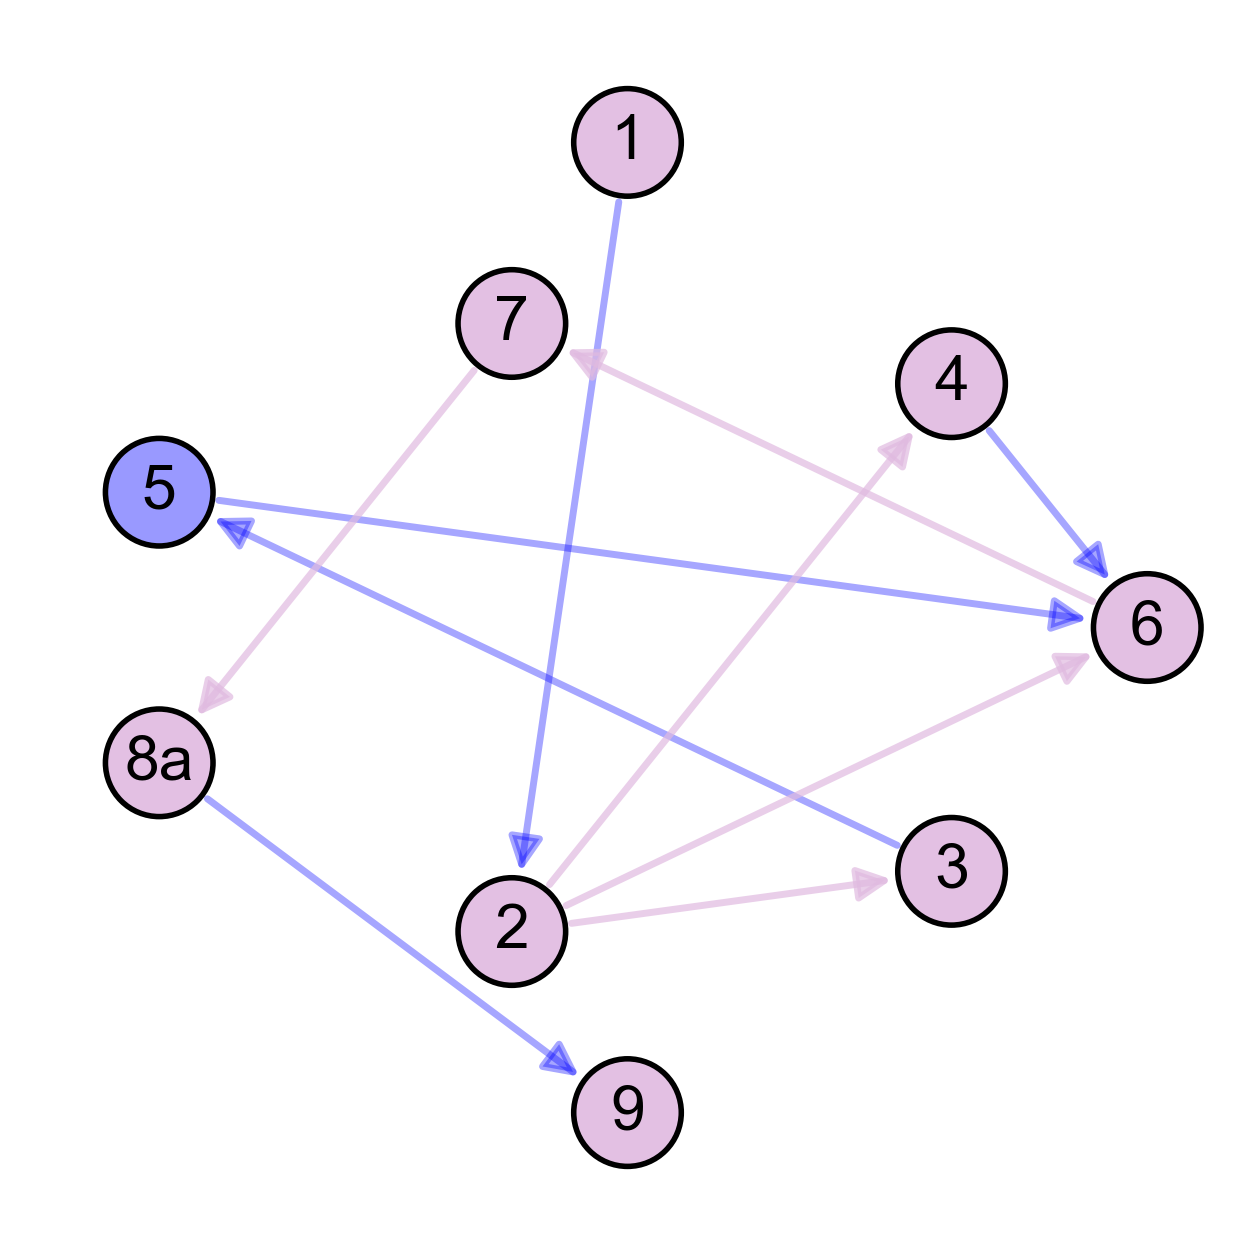

In [20]:
from reaction_networks import ReactionNetworkGenerator
# op9802125
rg = ReactionNetworkGenerator(
        dataset1_path="../data/OPRD-100.xlsx",
        dataset2_path="../data/Reaxys_data/reaxys_100_articles_data.xml",
        doi="op9802125",
        dataset1_name="OPRD-100",
        dataset2_name="Reaxys Dataset",
        mol_labels={
            "ClC1=C(C=C(S1)Cl)C(C)=O": "1",
            "ClC1=CC(C(C)=O)=C(S1)SCC2=CC=CC=C2":"2",
            "ClC1=CC(C(C)=O)=C(SCl)S1": "3",
            "ClC1=CC(C(C)=O)=C(S(Cl)(=O)=O)S1": "4",
            "ClC1=CC(C(C)=O)=C(S1)SNCCOC": "5",
            "ClC1=CC(C(C)=O)=C(S1)S(NCCOC)(=O)=O": "6",
            "ClC1=CC(C(CBr)=O)=C(S1)S(NCCOC)(=O)=O": "7",
            "ClC1=CC([C@H](O)CN2CCOC)=C(S1)S2(=O)=O": "8a",
            "O[C@@H](C1=C2SC(SCC3=CC=CC=C3)=C1)CN(CCOC)S2(=O)=O": "9",
            "O[C@@H](C1=C2SC(S(NC(C)(C)C)(=O)=O)=C1)CN(CCOC)S2(=O)=O": "10",
            "O[C@@H](C1=C2SC(S(N)(=O)=O)=C1)CN(CCOC)S2(=O)=O": "11a",
            "O[C@H](CN1CCOC)C2=C(S1(=O)=O)SC(S(=O)(N=C(C)OC)=O)=C2": "12",
            "COCCN1C[C@H](NCC)C2=C(S1(=O)=O)SC(S(=O)(N)=O)=C2": "13",
            "COCCNS(c1c(C(C)=O)cc(Cl)s1)=O": "X",
            "NSc1c(C(C)=O)cc(Cl)s1": "14",
            "NS(c1c(C(C)=O)cc(Cl)s1)=O": "15",
            "NS(c1c(C(C)=O)cc(Cl)s1)(=O)=O": "16",
            "NS(c1c(C(CBr)=O)cc(Cl)s1)(=O)=O": "17",
            "Clc1cc2c(S(NC[C@H]2O)(=O)=O)s1": "18",
            "COCCBr": "R",
            "COCCN": "R",
            "ClCc1ccccc1": "R",
            "SCc1ccccc1": "R",
        }
    )

rg.build_graph_from_nodes_edges(from_smiles="ClC1=C(C(C)=O)C=C(Cl)S1",
    to_smiles="O[C@@H](C1=C2SC(SCC3=CC=CC=C3)=C1)CN(CCOC)S2(=O)=O", hide_datasets=["Reaxys Dataset"],)

rg.draw_reaction_network_circular_clean(
        top_smiles=["ClC1=C(C(C)=O)C=C(Cl)S1"],   # List of SMILES strings to place at the top
        bottom_smiles=["O[C@@H](C1=C2SC(SCC3=CC=CC=C3)=C1)CN(CCOC)S2(=O)=O"], # List of SMILES strings to place at the bottom
        img_dpi = 500,
        label_fontsize = 9,
        auto_terminals=False,
        figsize=(3, 3),

        # ring layout
        circle_center=(0.5, 0.5),
        circle_radius=0.45,
        inner_radius=0.2,
        oval_ratio=0.6,  # flatten the ring into an oval for better edge separation
        # terminal bands
        top_y=0.92,
        bottom_y=0.08,
        # style
        node_size_molecule=240,
        node_size_intermediate=100,
        node_alpha=0.9,
        edge_alpha=0.35,
        edge_alpha_dataset1=0.35, edge_alpha_dataset2=0.35, edge_alpha_both=0.7,
        edge_width=1.0,
        # dataset colors (applied to nodes and edges)
        color_dataset1="blue",
        color_dataset2="#FF7701",
        color_both="#E0BAE0",
        color_dataset1_alpha=0.4, color_dataset2_alpha=0.4, color_both_alpha=0.9,
        ring_shuffle=True, ring_shuffle_seed=91,
        node_edgewidth=0.8,
        edge_border=False,
        label_fontcolor="black",
        label_mode="all",  # 'none' | 'terminals' | 'all'
        # layout refinement for inner nodes
        use_spring_for_inner=False,
        spring_iterations=200,
        spring_k=None,
        clamp_inner_to_radius=True,
        seed=20,
        # output
        show_legend=False,
        savefig=True,
        filename=filepath+"op9802125_scheme_1_OPRD-100_reaction_network.png",
)
